Data Loading


In [8]:
import kagglehub
import pandas as pd
import os

#download the dataset
path = kagglehub.dataset_download("shashwatwork/dataco-smart-supply-chain-for-big-data-analysis")

#load the main dataset (using latin-1 encoding as this file often has special characters)
csv_path = os.path.join(path, 'DataCoSupplyChainDataset.csv')
df = pd.read_csv(csv_path, encoding='latin-1')

#print first 5 records
print(df.head())
print(df.info())

Using Colab cache for faster access to the 'dataco-smart-supply-chain-for-big-data-analysis' dataset.
       Type  Days for shipping (real)  Days for shipment (scheduled)  \
0     DEBIT                         3                              4   
1  TRANSFER                         5                              4   
2      CASH                         4                              4   
3     DEBIT                         3                              4   
4   PAYMENT                         2                              4   

   Benefit per order  Sales per customer   Delivery Status  \
0          91.250000          314.640015  Advance shipping   
1        -249.089996          311.359985     Late delivery   
2        -247.779999          309.720001  Shipping on time   
3          22.860001          304.809998  Advance shipping   
4         134.210007          298.250000  Advance shipping   

   Late_delivery_risk  Category Id   Category Name Customer City  ...  \
0                  

Data Cleaning


In [3]:
# Use the exact names from your verified list
logistics_cols = [
    'Type',
    'Days for shipping (real)',
    'Days for shipment (scheduled)',
    'Late_delivery_risk',
    'Order Region',
    'Order Status',
    'Shipping Mode',
    'Order Profit Per Order',
    'Sales'
]

df_clean = df[logistics_cols].copy()

# Calculate the Efficiency Gap (How many days late/early)
df_clean['Delivery_Gap'] = df_clean['Days for shipping (real)'] - df_clean['Days for shipment (scheduled)']

print(f"New shape:",df_clean.shape)
print(df_clean.head())

New shape: (180519, 10)
       Type  Days for shipping (real)  Days for shipment (scheduled)  \
0     DEBIT                         3                              4   
1  TRANSFER                         5                              4   
2      CASH                         4                              4   
3     DEBIT                         3                              4   
4   PAYMENT                         2                              4   

   Late_delivery_risk    Order Region     Order Status   Shipping Mode  \
0                   0  Southeast Asia         COMPLETE  Standard Class   
1                   1      South Asia          PENDING  Standard Class   
2                   0      South Asia           CLOSED  Standard Class   
3                   0         Oceania         COMPLETE  Standard Class   
4                   0         Oceania  PENDING_PAYMENT  Standard Class   

   Order Profit Per Order   Sales  Delivery_Gap  
0               91.250000  327.75            -1 

Determining effect of Payment time on delivery delay

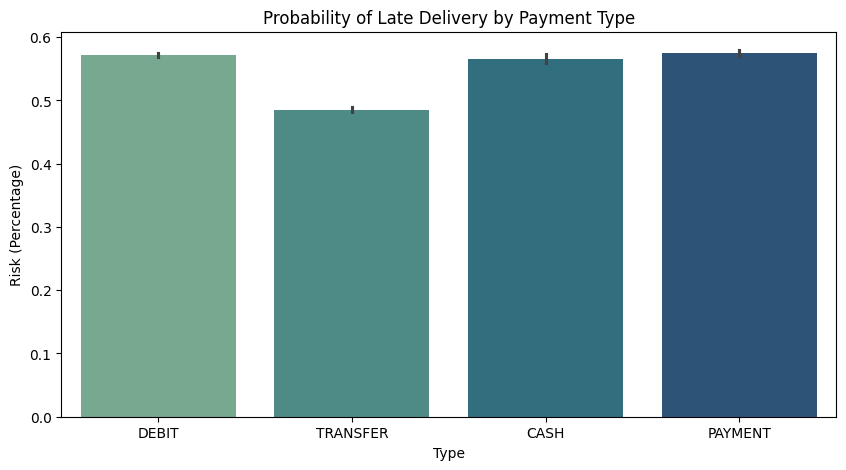

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.barplot(x='Type', y='Late_delivery_risk', data=df_clean, hue='Type', palette='crest', legend=False)
plt.title('Probability of Late Delivery by Payment Type')
plt.ylabel('Risk (Percentage)')
plt.show()

While Debit, Cash, and Payment all hover between 55% and 58% risk, Transfer sits below 50%.

This suggests that bank transfer orders might be processed through a different fulfillment channel, or perhaps they are subject to stricter verification that inadvertently aligns better with shipping schedules. The "manual" nature of Cash or the "instant" nature of Debit doesn't seem to change the shipping speed. This implies that once an order is "cleared," it hits the same logistical bottleneck regardless of the source of funds.

Since the error bars are very short, it means the sample size is large and these results are very reliable.

Effect of delay in delivery based on shipping mode (First Class/Second Class/Standard Class)


/tmp/ipython-input-3301039368.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Shipping Mode', y='Delivery_Gap', data=df_clean, ax=axes[0], palette='Set2')


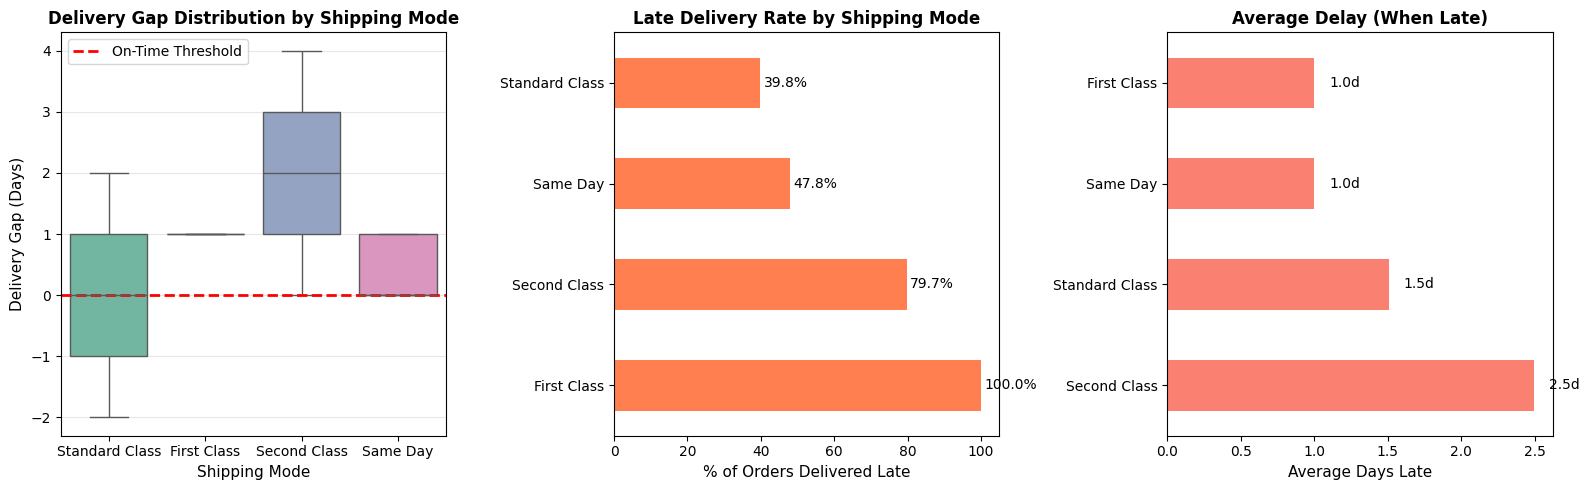


=== Delivery Performance Summary ===
                Total Orders  Avg Gap  Median Gap  Late Count  Late %
Shipping Mode                                                        
First Class            27814     1.00         1.0       27814   100.0
Same Day                9737     0.48         0.0        4657    47.8
Second Class           35216     1.99         2.0       28078    79.7
Standard Class        107752    -0.00         0.0       42851    39.8


In [14]:
# Create figure with multiple panels
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: Boxplot with better annotations
sns.boxplot(x='Shipping Mode', y='Delivery_Gap', data=df_clean, ax=axes[0], palette='Set2')
axes[0].axhline(0, color='red', linestyle='--', linewidth=2, label='On-Time Threshold')
axes[0].set_title('Delivery Gap Distribution by Shipping Mode', fontweight='bold')
axes[0].set_ylabel('Delivery Gap (Days)', fontsize=11)
axes[0].set_xlabel('Shipping Mode', fontsize=11)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Panel 2: Late delivery rate (more actionable!)
late_rates = (
    df_clean.groupby('Shipping Mode')['Delivery_Gap']
    .agg(lambda x: (x > 0).mean() * 100)  # mean of boolean = percentage
    .sort_values(ascending=False)
)

late_rates.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Late Delivery Rate by Shipping Mode', fontweight='bold')
axes[1].set_xlabel('% of Orders Delivered Late', fontsize=11)
axes[1].set_ylabel('')
for i, v in enumerate(late_rates):
    axes[1].text(v + 1, i, f'{v:.1f}%', va='center')

# Panel 3: Average delay for late deliveries only
avg_delay = df_clean[df_clean['Delivery_Gap'] > 0].groupby('Shipping Mode')['Delivery_Gap'].mean().sort_values(ascending=False)

avg_delay.plot(kind='barh', ax=axes[2], color='salmon')
axes[2].set_title('Average Delay (When Late)', fontweight='bold')
axes[2].set_xlabel('Average Days Late', fontsize=11)
axes[2].set_ylabel('')
for i, v in enumerate(avg_delay):
    axes[2].text(v + 0.1, i, f'{v:.1f}d', va='center')

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n=== Delivery Performance Summary ===")
summary = df_clean.groupby('Shipping Mode').agg({
    'Delivery_Gap': ['count', 'mean', 'median', lambda x: (x > 0).sum()]
}).round(2)
summary.columns = ['Total Orders', 'Avg Gap', 'Median Gap', 'Late Count']
summary['Late %'] = (summary['Late Count'] / summary['Total Orders'] * 100).round(1)
print(summary)

This boxplot reveals a systemic failure in premium shipping tiers. While 'Standard Class' meets its schedule 50% of the time, 'First Class' and 'Second Class' modes have a near-100% failure rate, indicating that the scheduled delivery windows for these tiers are mathematically unrealistic.

Finding risk of delay based on product category

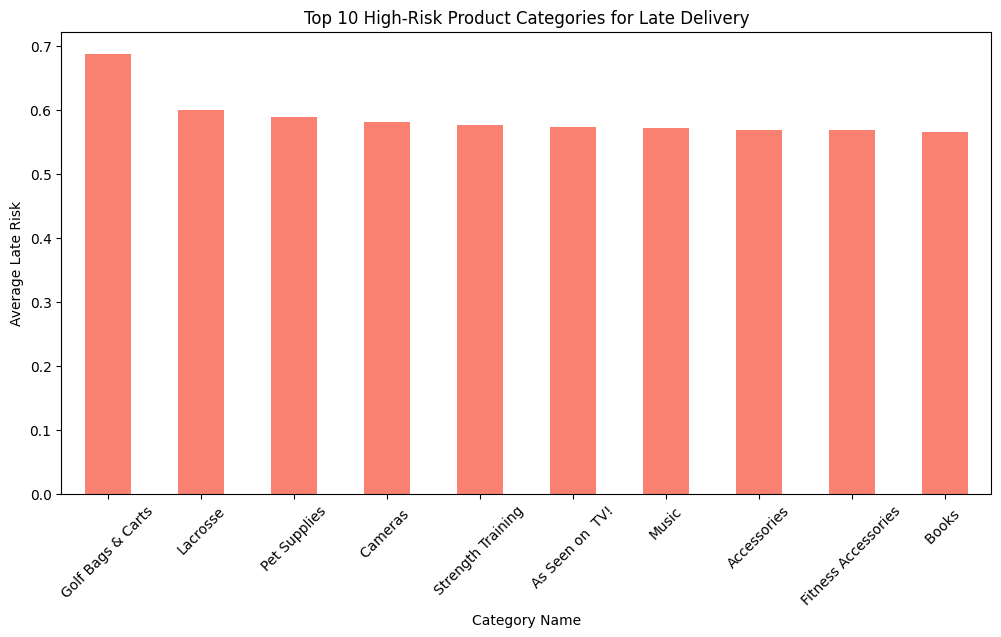

In [ ]:
# Add Category Name to our clean dataframe
df_clean['Category Name'] = df['Category Name']

# Calculate average risk per category and pick the top 10 most risky
top_10_risky = df_clean.groupby('Category Name')['Late_delivery_risk'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
top_10_risky.plot(kind='bar', color='salmon')
plt.title('Top 10 High-Risk Product Categories for Late Delivery')
plt.ylabel('Average Late Risk')
plt.xticks(rotation=45)
plt.show()

The chart shows that the top ten product categories all have a very high average risk of late delivery, ranging roughly from 0.56 to 0.69, which means that more than half of the orders in these categories tend to arrive late. Golf Bags & Carts stand out with the highest risk, indicating a particularly severe delivery issue compared to the others. Many of these categories involve bulky, heavy, or non-standard items that require special handling and do not move efficiently through standard courier networks. n addition, categories driven by trends or promotions often experience sudden demand spikes, which leads to stockouts and backorders. Some of these products are also non-essential, so they may receive lower priority in logistics operations.

Missing values per feature:
Type                             0
Shipping Mode                    0
Order Region                     0
Days for shipment (scheduled)    0
Category Name                    0
dtype: int64

Class distribution:
Late_delivery_risk
1    0.548291
0    0.451709
Name: proportion, dtype: float64

Training shape: (144415, 78)
Test shape: (36104, 78)

Cross-val ROC-AUC: 0.742 (+/- 0.003)

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.62      0.87      0.72     16308
           1       0.84      0.55      0.67     19796

    accuracy                           0.70     36104
   macro avg       0.73      0.71      0.69     36104
weighted avg       0.74      0.70      0.69     36104

ROC-AUC Score: 0.744

Top 10 Important Features:
                          feature  importance
0   Days for shipment (scheduled)    0.446011
6    Shipping Mode_Standard Class    0.341441
5      Shipping Mode_Second Class    0.103733


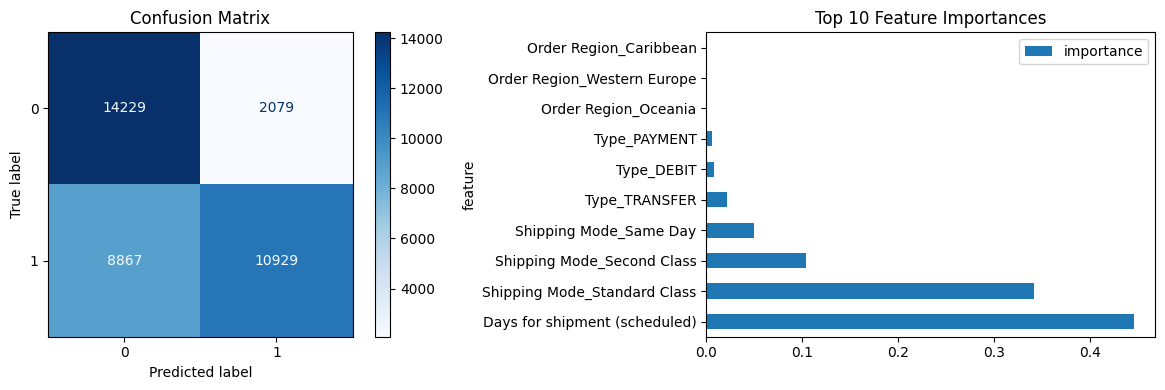

In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_auc_score
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve



# 1. Feature selection
features = ['Type', 'Shipping Mode', 'Order Region',
            'Days for shipment (scheduled)', 'Category Name']

# Check for missing values
print("Missing values per feature:")
print(df[features].isnull().sum())

X = df[features].copy()
y = df['Late_delivery_risk']

# Check class balance
print(f"\nClass distribution:\n{y.value_counts(normalize=True)}")

# 2. Train-test split FIRST
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # stratify preserves class balance
)

# 3. One-hot encode (fit on train, transform both)
X_train_encoded = pd.get_dummies(X_train, drop_first=True)  # drop_first avoids multicollinearity
X_test_encoded = pd.get_dummies(X_test, drop_first=True)
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

print(f"\nTraining shape: {X_train_encoded.shape}")
print(f"Test shape: {X_test_encoded.shape}")


# 4. Train model with class balancing
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    random_state=42,
    class_weight='balanced',  # Handle imbalance
    n_jobs=-1  # Use all cores
)

rf_model.fit(X_train_encoded, y_train)

# 5. Cross-validation on training set
cv_scores = cross_val_score(rf_model, X_train_encoded, y_train, cv=5, scoring='roc_auc')
print(f"\nCross-val ROC-AUC: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")

# 6. Predictions
y_pred = rf_model.predict(X_test_encoded)
y_pred_proba = rf_model.predict_proba(X_test_encoded)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
# 7. Comprehensive evaluation
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.3f}")

# 8. Feature importance
feature_importance = pd.DataFrame({
    'feature': X_train_encoded.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Important Features:")
print(feature_importance.head(10))

# 9. Visualizations
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(rf_model, X_test_encoded, y_test,
                                      cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix')

# Feature Importance
feature_importance.head(10).plot(x='feature', y='importance', kind='barh', ax=axes[1])
axes[1].set_title('Top 10 Feature Importances')

plt.tight_layout()
plt.show()

These results show a well-performing and stable classification model with meaningful predictive power. The dataset is clean (no missing values) and only mildly imbalanced, which is properly handled through stratification and class weighting. The model achieves a ROC-AUC of ~0.74, both in cross-validation and on the test set, indicating consistent ability to distinguish between late and on-time deliveries beyond random guessing. Accuracy is ~70%, with a clear asymmetry in class performance: the model has high recall for on-time deliveries (0.87) but lower recall for late deliveries (0.55), meaning it still misses a notable portion of late orders, even though when it predicts a delay, it is usually correct (precision 0.84).
Feature importance strongly indicates that logistics-related factors dominate predictions, especially Days for shipment (scheduled) and Shipping Mode, which together explain the vast majority of model decisions, while order type and region play only a minor role. Overall, this confirms that late delivery risk is driven primarily by shipping design choices rather than customer or regional effects, and the model is suitable for risk scoring, especially if further tuned to improve recall for late deliveries.